<p align="center">
  <a href="https://vicena.ai"><strong>Built with Vicena</strong></a>
</p>

# Held-out validation

This notebook is part of the Vicena Research Twins collection.

## Purpose and scientific status
Evaluate a declared held-out synthetic dataset without tuning parameters on it.

## Inputs and units
Concentration: mol/m3. Time: s. Temperature: K. Observation uncertainty must use the same units as the target.

## Execution and printed results
The notebook prints RMSE, MAE, relative error, chi-square, and solver diagnostics, then displays residuals.

## Validation and limitations
Residual structure matters in addition to aggregate metrics. Synthetic validation is Level 0 evidence only.

In [3]:
import sys
from pathlib import Path
root=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd(); sys.path.insert(0,str(root/'src'))
import numpy as np
import matplotlib.pyplot as plt
from chemical_reactor_twin import ReactionNetwork, simulate_batch
from chemical_reactor_twin.analysis import validate_prediction

{'rmse': 2.0814040648457652, 'mae': 1.646228242701277, 'max_abs_error': 5.044654821498869, 'mean_relative_error': 0.7533914471916562, 'n': 41, 'reduced_chi_square': 1.0830607202891185}
solver diagnostics {'success': True, 'message': 'The solver successfully reached the end of the integration interval.', 'nfev': 505, 'njev': 1, 'method': 'BDF', 'rtol': 1e-07, 'atol': 1e-09, 'min_concentration': 0.0, 'max_temperature_K': 345.00154536449156}


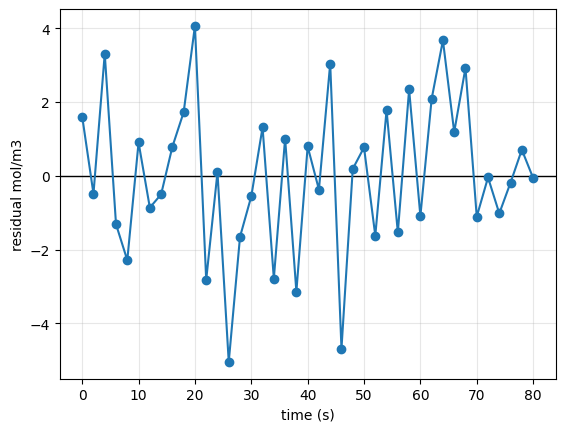

In [4]:
net=ReactionNetwork(['A','B'],[[-1,1]],[12.0],[11000.0],[[1,0]],[-10000.0])
r=simulate_batch(net,[1000,0],345,80,ua=1e9,coolant_temperature=345,n_points=41)
rng=np.random.default_rng(9); observed=r.concentration[:,0]+rng.normal(0,2,len(r.coordinate))
metrics=validate_prediction(observed,r.concentration[:,0],sigma=np.full(len(observed),2.0))
print(metrics); print('solver diagnostics',r.diagnostics)
plt.axhline(0,color='k',lw=1); plt.plot(r.coordinate,r.concentration[:,0]-observed,'o-'); plt.xlabel('time (s)'); plt.ylabel('residual mol/m3'); plt.grid(alpha=.3); plt.show()